# Prepare Data

In [27]:
from emulator.interpolator import util
import matplotlib.pyplot as plt
import astropy.units as u
import pandas as pd
import numpy as np
import corner
import os
from scipy.interpolate import interp1d
from IPython.display import display
%matplotlib widget
def show_active():
    fig = plt.gcf()
    display(fig)
    plt.close(fig)

# Fit settings
fit_max_wav = 10000 # 7000
fit_min_wav = 5100 # 5100

# Get model data
param_names, X, y, wav_mod = util.read_runs('new_atomic_runs')
bad_indices = [20, 25, 27, 29, 50, 272, 273, 314, 350, 372, 397, 406, 465, 481, 631, 645, 682, 923, 935, 958, 983, 1078, 1129, 1144, 1225, 1268, 1275, 1298, 1300, 1346, 1433, 1606, 1743, 1904, 1953, 1975, 2139, 2156, 2194, 2242, 2457, 2523, 2544, 2615, 2638, 2664, 2708, 2859, 2904, 3046, 3055, 3182, 3317, 3338, 3358, 3405, 3433, 3620, 3773, 3797, 3808, 3851, 3892, 3910, 3918, 4024, 4043, 4052, 4079, 4175, 4199, 4328, 4375, 4409, 4432, 4499, 4500, 4559, 4572, 4758, 4792, 4877, 4883, 4916, 4928, 5111, 5161, 5325, 5364, 5390, 5448, 5459, 5527, 5570, 5683, 5812, 5818, 5819, 5832, 5996, 6197, 6417, 6519, 6684, 6709, 6806, 6844, 6924, 6985, 7062, 7120, 7204, 7263, 7275, 7300, 7353, 7444, 7541, 7567, 7598, 7602, 7703, 7755, 7883, 7921, 8096, 8115, 8439]
X, y = util.remove_bad_indices(X, y, bad_indices)
param_names2, X2, y2, wav_mod2 = util.read_runs('new_atomic_runs_2')
X = np.vstack((X, X2))
y = np.vstack((y, y2))

# Get observed data
obs_df = pd.read_csv('calibrated_spectra/2020jfo-2020-05-19.csv')
wav_obs = obs_df['wavelength']
y_obs = obs_df['flux']
y_obs_err = y_obs * 0.01 # obs_df['fluxerr']

print(param_names)
print(y.shape)

['log_lsun' 't_exp' 'v_start' 'X' 'Z' 'n']
(13401, 1000)


In [28]:
# View other stored spectra
if False:
    obs_df = pd.read_csv('calibrated_spectra/2020hgw-2020-05-23.csv')
    wav_obs = obs_df['wavelength']
    y_obs = obs_df['flux']
    plt.figure()
    plt.plot(wav_obs, y_obs)
    plt.xlim(5100, 7000)
    plt.ylim(0, 3e-16)
    show_active()

if False:
    spec_dir = 'calibrated_spectra/'
    plt.figure()

    for name in os.listdir(spec_dir):
        spec_path = os.path.join(spec_dir, name)
        if os.path.isfile(spec_path):
            print(name)
            df = pd.read_csv(spec_path)
            wav_obs = df['wavelength']
            y_obs = df['flux']
            plt.plot(wav_obs, y_obs / np.mean(y_obs), label=name, lw=1)
    plt.legend()
    plt.xlim(5000, 7000)
    plt.ylim(0, 2)
    plt.show()

In [29]:
# Initialize model data file
if False:
    from emulator.interpolator import util
    import os
    folder_path = os.path.dirname('C:/Users/mikel/Desktop/new_atomic_runs_2/')
    param_names = ['log_lsun', 't_exp', 'v_start', 'X', 'Z', 'n']
    util.save_runs(folder_path, param_names, 'new_atomic_runs_2')

In [30]:
# Mask to fitting range
mask = (wav_obs < fit_max_wav) & (wav_obs > fit_min_wav)
wav_obs = wav_obs[mask]
y_obs = y_obs[mask]
y_obs_err = y_obs_err[mask]

# Remove any spectra containing negative fluxes
mask = np.all(y >= 0, axis=1)
X = X[mask]
y = y[mask]

# Remove the out of range model data
mask = (wav_mod >= wav_obs.min()) & (wav_mod <= wav_obs.max())
wav_mod = wav_mod[mask]
y = y[:, mask]

# Interpolate onto new wavelength grid
dx = np.max([np.abs(wav_mod[-1] - wav_mod[-2]), np.abs(wav_mod[1] - wav_mod[0])])
wav = np.arange(wav_mod.min(), wav_mod.max(), dx)
y = interp1d(wav_mod, y, bounds_error=False)(wav)
y_obs = interp1d(wav_obs, y_obs, bounds_error=False)(wav)
y_obs_err = interp1d(wav_obs, y_obs_err, bounds_error=False)(wav)

# Setup fitting parameters
param_limits = list(zip(np.min(X, axis=0), np.max(X, axis=0)))
param_indices = {value: index for index, value in enumerate(param_names)}
sampler_names = param_names.copy()
sampler_limits = param_limits.copy()
sampler_indices = param_indices.copy()
ndim = len(sampler_names)

# Setup continuum removal function
line_mask = ((wav > 6200) & (wav < 6900)) | ((wav > 4550) & (wav < 4900))
from numpy.polynomial import Polynomial
def continuum_removal(y_mod):
    c = Polynomial.fit(wav[~line_mask], y_obs[~line_mask]/y_mod[~line_mask], deg=3)
    p = c(wav)
    return p * y_mod

print(pd.DataFrame({'name': sampler_names, 'limits': list(sampler_limits)}))

       name                                      limits
0  log_lsun      (7.320048387505541, 9.119777760813308)
1     t_exp     (10.001412657796452, 18.99924654464823)
2   v_start      (5600.420224087724, 9997.277362290575)
3         X     (0.5500184029803851, 0.949918040459742)
4         Z  (0.0005011675428490001, 0.049998573782612)
5         n     (5.010847610730749, 14.997641691449374)


In [31]:
# Look for bad spectra
if False:
    y_norm = y - y.min(axis=1, keepdims=True)
    y_norm = y_norm / y_norm.max(axis=1, keepdims=True)

    plt.figure()
    bad_i = []
    for i, y_i in enumerate(y_norm):
        curvature = np.std(np.diff(y_i, n=2))
        if curvature < 3e-3:
            bad_i.append(i)

    print(bad_i)
    for i in bad_i:
        plt.plot(wav, y_norm[i])
    show_active()

    mask = np.isin(np.arange(len(X)), bad_i)
    fig = corner.corner(
        X[mask],
        labels=param_names,
        range=param_limits,
        bins=20,
        plot_contours=False,
        plot_datapoints=False,
        plot_density=True,
    )
    show_active()

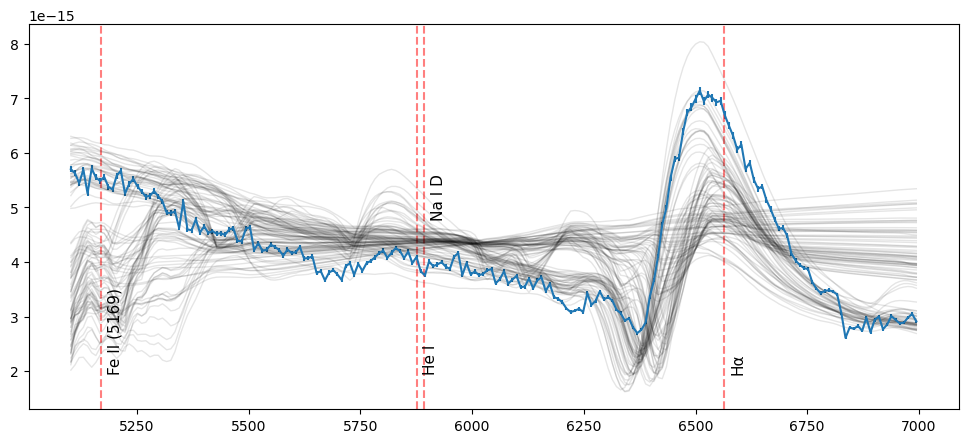

In [32]:
# View observed data
plt.figure(figsize=(12, 5))
plt.errorbar(wav, y_obs, yerr=y_obs_err, ms=1)
util.label_common_features()

# Overlay models
for y_mod in y[:100]:
    plt.plot(wav, y_mod / np.mean(y_mod) * np.mean(y_obs), c='black', lw=1, alpha=0.1)

show_active()

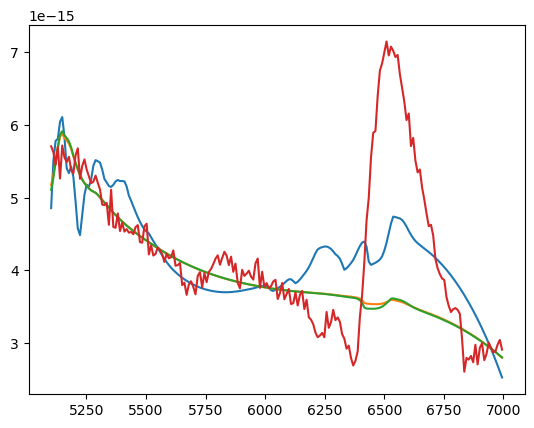

In [33]:
# Simple minimze MSE fit
mse = []
for y_mod in y:
    y_mod_corr = continuum_removal(y_mod)
    # y_mod_norm = y_mod_corr / y_mod_corr.mean()
    # y_obs_norm = y_obs / y_obs.mean()
    # mse.append(np.mean((y_mod_norm - y_obs_norm)**2))
    mse.append(np.mean((y_obs - y_mod_corr)**2/y_obs_err**2))

plt.figure()
order = np.argsort(mse)
for i in range(3):
    lowest_i = i
    # lowest_i = np.argmin(mse)
    X_best = X[lowest_i]
    y_best = continuum_removal(y[lowest_i])

    plt.plot(wav, y_best)
plt.plot(wav, y_obs)
# plt.plot(wav, y_best / np.mean(y_best))
# plt.plot(wav, y_obs / np.mean(y_obs))

# distance = util.distance(np.mean(y_best) / np.mean(y_obs))
# print(distance)
# print('X:', dict(zip(sampler_names, X_best)))

show_active()

Spectra shape: (13315, 204)


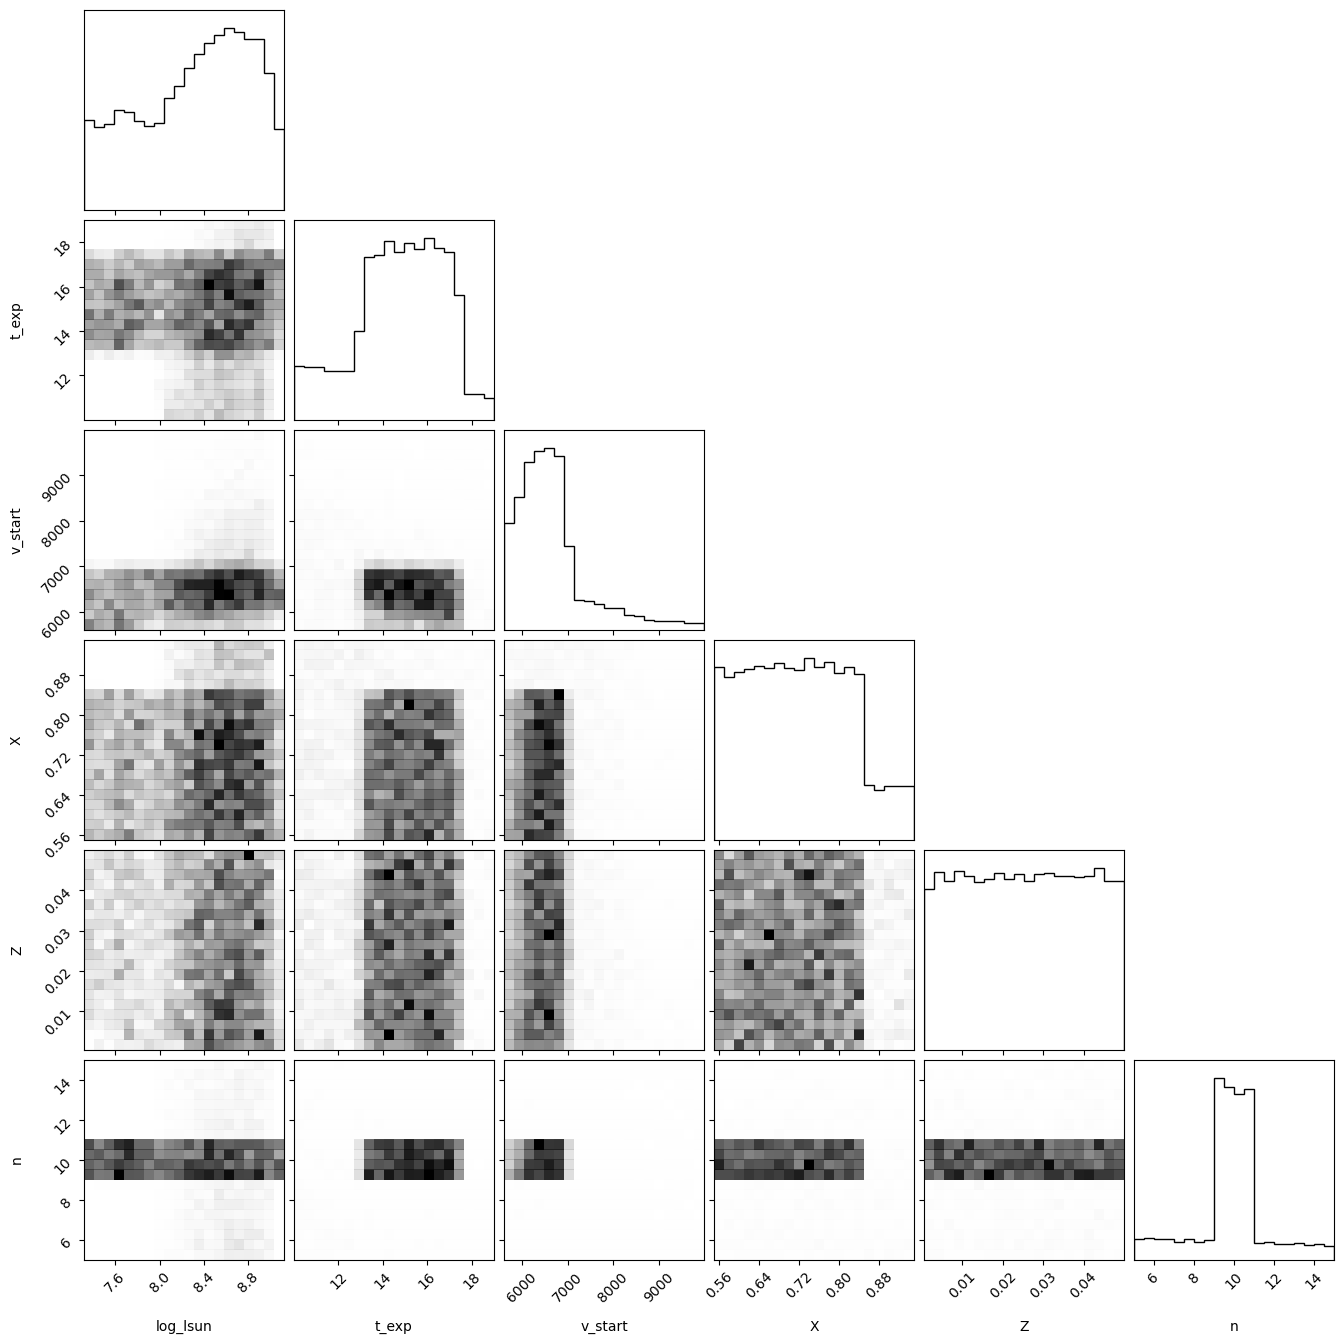

In [34]:
# Visualize sampling coverage
print('Spectra shape:', y.shape)
fig = corner.corner(
    X,
    labels=param_names,
    range=param_limits,
    bins=20,
    plot_contours=False,
    plot_datapoints=False,
    plot_density=True,
)
show_active()

# Train Models

In [35]:
removed_v_start = False

# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

In [36]:
# Linear interpolator
if False:
    from sklearn.preprocessing import MinMaxScaler
    from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_train)
    interp_linear_scaled = LinearNDInterpolator(X_scaled, y_train)
    interp_nearest_scaled = NearestNDInterpolator(X_scaled, y_train)

    def nearest_multiple(X_mod):
        X_scaled = scaler.transform(X_mod)
        return interp_nearest_scaled(X_scaled)
    def nearest_single(X_mod):
        X_scaled = scaler.transform(X_mod.reshape(1, -1))
        return interp_nearest_scaled(X_scaled)
    
    def linear_multiple(X_mod):
        X_scaled = scaler.transform(X_mod)
        y = interp_linear_scaled(X_scaled)
        if np.any(np.isnan(y)):
            return interp_nearest_scaled(X_scaled)
        else:
            return y
    def linear_single(X_mod):
        X_scaled = scaler.transform(X_mod.reshape(1, -1))
        y = interp_linear_scaled(X_scaled)
        if np.any(np.isnan(y)):
            return interp_nearest_scaled(X_scaled)
        else:
            return y

In [37]:
# MLPRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, QuantileTransformer, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.decomposition import PCA

mlp = MLPRegressor(
    max_iter=10000, alpha=1e-3, tol=1e-14, learning_rate_init=1e-3, hidden_layer_sizes=(128, 128, 64), early_stopping=False
)

model = TransformedTargetRegressor(
    regressor=Pipeline([
        ('x_scaler', StandardScaler()),
        ('mlp', mlp),
    ]),
    transformer=Pipeline([
        # ('y_scaler', StandardScaler()),
        ('log', FunctionTransformer(np.log1p, inverse_func=np.expm1)),
        ('pca', PCA(n_components=30)),
    ]),
)

model.fit(X_train, y_train)
print('Iterations:', model.regressor_.named_steps['mlp'].n_iter_)
pca = model.transformer_.named_steps['pca']
print('PCA variance:', pca.explained_variance_ratio_.sum())

def mlp_multiple(X_mods):
    if removed_v_start:
        for X_mod in X_mods:
            X_mod = np.insert(X_mod, sampler_indices['v_start'], 0)
            v_phot = util.calc_v_phot(t_exp=X_mod[sampler_indices['t_exp']], X=X_mod[sampler_indices['X']], n=X_mod[sampler_indices['n']])
            X_mod[sampler_indices['v_start']] = v_phot
    return model.predict(X_mods)
def mlp_single(X_mod):
    if removed_v_start:
        X_mod = np.insert(X_mod, sampler_indices['v_start'], 0)
        v_phot = util.calc_v_phot(t_exp=X_mod[sampler_indices['t_exp']], X=X_mod[sampler_indices['X']], n=X_mod[sampler_indices['n']])
        X_mod[sampler_indices['v_start']] = v_phot
    return model.predict(X_mod.reshape(1, -1))[0]

c:\Users\mikel\anaconda3\Lib\site-packages\sklearn\compose\_target.py:196: UserWarning: The provided functions or transformer are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'
  warnings.warn(


Iterations: 192
PCA variance: 0.999985968657026


In [50]:
# Remove v_start from the sampler lists after models are trained with it
if 'v_start' in sampler_names:
    sampler_names = np.delete(sampler_names, sampler_indices['v_start'])
    del sampler_limits[sampler_indices['v_start']]
    removed_v_start = True
sampler_input_indices = {value: index for index, value in enumerate(sampler_names)}

In [39]:
# Find hyperparameters
if False:
    from sklearn.neural_network import MLPRegressor
    from sklearn.model_selection import GridSearchCV
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import Pipeline
    from sklearn.metrics import mean_squared_error

    mlp = MLPRegressor(
        max_iter=10000, tol=1e-6, early_stopping=True
    )
    model = TransformedTargetRegressor(
        regressor=Pipeline([
            ('x_scaler', StandardScaler()),
            ('mlp', mlp),
        ]),
        transformer=StandardScaler(),
    )

    param_grid = {
        'regressor__mlp__hidden_layer_sizes': [
            (32,),
            (64,),
            (128,),
            (64, 64),
            (128, 64),
            (128, 128),
        ],
        'regressor__mlp__alpha': [
            1e-5,
            1e-4,
            1e-3,
            1e-2,
        ],
        'regressor__mlp__learning_rate_init': [
            1e-4,
            5e-4,
            1e-3,
        ]
    }

    search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    results = pd.DataFrame(search.cv_results_).sort_values('rank_test_score')
    print(results[['param_regressor__mlp__hidden_layer_sizes', 'std_test_score']])

    y_pred = best_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print('Test MSE:', mse)
    print(search.best_params_)


# Model Diagnositcs

In [15]:
import importlib
import util
importlib.reload(util)

<module 'util' from '\\\\wsl.localhost\\Ubuntu\\home\\mikel\\GitHub\\iip-emulator\\emulator\\interpolator\\util.py'>

In [ ]:
# Compare noise
if False:
    plt.figure()
    X_diag = np.mean(param_limits, axis=1) # X_diag = X_best
    plt.plot(wav, linear_single(X_diag, force_nearest=False)[0], label='Linear')
    plt.plot(wav, nearest_single(X_diag, force_nearest=True)[0], label='Nearest')
    plt.plot(wav, mlp_single(X_diag.reshape(1, -1))[0], label='MLPRegressor')
    plt.title('Noise Comparison')
    plt.legend()
    show_active()

# The histogram excludes mfe values larger than the 95th percentile, since there's a few outliers
# Dotted lines are the actual test models
util.evaluate_predictions(y_test, linear_multiple(X_test), wav, 'Linear Interpolator Test Set Predictions, 95th Percentile')
show_active()
mfe = util.evaluate_predictions(y_test, mlp_multiple(X_test), wav, 'MLPRegressor Test Set Predictions, 95th Percentile')
show_active()

NameError: name 'linear_multiple' is not defined

In [ ]:
if False:
    # Look at the spectra producing bad results
    plt.figure()
    mask = mfe > 0.4
    bad_X = X_test[mask]
    bad_y = y_test[mask]
    for i in range(len(bad_y)):
        y_i = bad_y[i]
        y_i -= y_i.min()
        plt.plot(wav, y_i / y_i.max())
    show_active()

    # Get indices for these bad spectra
    bad_i = [np.where((X == row).all(axis=1))[0][0] for row in bad_X]
    print(bad_i)

# Scipy Fit

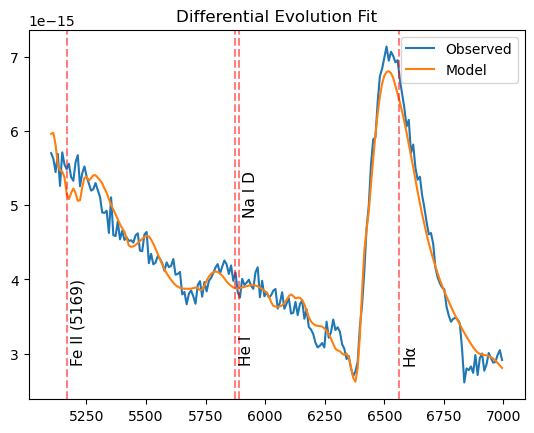

data =  {'log_lsun': 7.962654584751952, 't_exp': 13.773102940555766, 'X': 0.6857043001929232, 'Z': 0.013214953236852721, 'n': 14.997638787191548}


In [40]:
# Scipy differential evolution
results = []

def f(X_mod):
    y_mod = continuum_removal(mlp_single(X_mod))
    like = (((y_mod - y_obs) / y_obs_err)**2).sum()
    return like

from scipy.optimize import differential_evolution
sampler_start = list(np.mean(sampler_limits, axis=1))
result = differential_evolution(f, x0=sampler_start, bounds=sampler_limits, tol=1e-6)

X_mod = result.x
y_mod = continuum_removal(mlp_single(X_mod))
plt.figure()
plt.plot(wav, y_obs, label='Observed')
plt.plot(wav, y_mod, label='Model')
plt.title('Differential Evolution Fit')
plt.legend()
util.label_common_features()
show_active()

# distance = util.distance(scale)
# print('distance:', distance.to(u.Mpc))
print('data = ', dict(zip(sampler_names, X_mod)))

# Lightcurve

In [ ]:
# Extract the necessary data for the synthetic photometric datapoint
v_phot = util.calc_v_phot(t_exp=X[:,1], X=X[:,3], n=X[:,5]).reshape(-1, 1)
X_mod_0 = dict(zip(param_names, X_mod))
log_scale = result.x[-1]
spec_mjd = 58988.502581

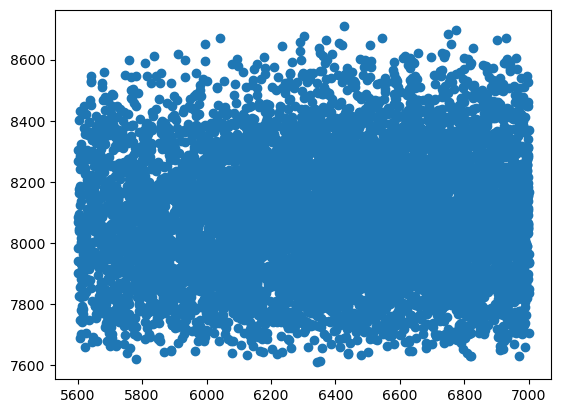

In [22]:
plt.figure()
plt.scatter(X[:,2], v_phot)
show_active()

In [ ]:
# Build v_start estimator, dependent on only time with all other variables held fixed
v_start_mlp = MLPRegressor(
    max_iter=10000, alpha=1e-3, tol=1e-14, learning_rate_init=1e-3, hidden_layer_sizes=(128, 128, 64), early_stopping=False
)

v_start_model = TransformedTargetRegressor(
    regressor=Pipeline([
        ('x_scaler', StandardScaler()),
        ('mlp', v_start_mlp),
    ]),
)
mask = param_names != 'v_start'
index = np.where(param_names == 'v_start')[0][0]
v_start_model.fit(np.hstack((X[:,mask], v_phot)), X[:,index])

def get_v_start(X_mod, t_exp, v_phot):
    X_eval = X_mod.copy()
    X_eval[1] = t_exp
    X_eval = np.hstack((X_eval[mask], v_phot))
    v_start = v_start_model.predict(X_eval.reshape(1, -1))[0]
    return v_start

(8428, 1)


IndexError: boolean index did not match indexed array along dimension 1; dimension is 6 but corresponding boolean dimension is 1000

In [ ]:
R_0 = X_mod_0['v_start'] * X_mod_0['t_exp']
t_exp = X_mod_0['t_exp'] - 1
v_start = get_v_start(X_mod, t_exp, R_0 / t_exp)
print(v_start)

10646.422278942802


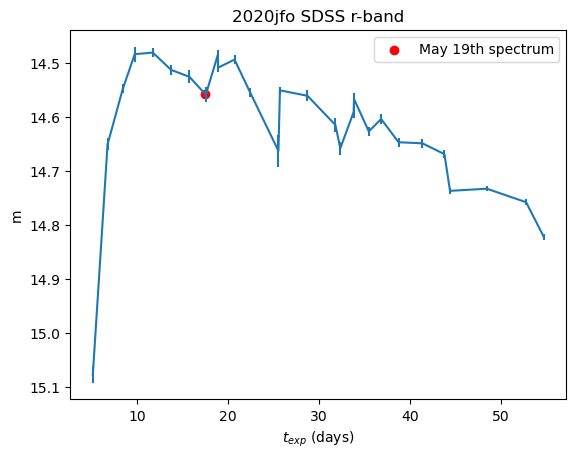

In [ ]:
# Get observational data
df = pd.read_csv('C:/Users/mikel/Desktop/2020jfo_data.snana.txt', comment='#', sep=r'\s+')

def get_mags(flt):
    data = df[df['FLT'] == flt]
    t = data['MJD'].values
    m = data['MAG'].values
    m_err = data['MAGERR'].values

    # Zero point should represent the start of the explosion
    t -= spec_mjd - t_exp
    sorted = np.argsort(t)
    t = t[sorted]
    m = m[sorted]
    m_err = m_err[sorted]

    mask = (t > 0) & (t < 60) & (data['DQ'] != 'Bad')
    t = t[mask]
    m = m[mask]
    m_err = m_err[mask]
    return t, m, m_err

t, m, m_err = get_mags('rp')
plt.figure()
plt.title('2020jfo SDSS r-band')
plt.xlabel(r'$t_{exp}$ (days)')
plt.ylabel('m')
plt.errorbar(t, m, np.abs(m_err))
plt.scatter(t_exp, interp1d(t, m)(t_exp), c='red', label='May 19th spectrum')
plt.gca().invert_yaxis()
plt.legend()
show_active()

In [ ]:
from emulator.grid_run.lc import get_sdss_flt

def photometry(log_scale, flt_wave, flt_trans, t_exp, wav, y_mod, y_mod_0, t_0, m_0):
    scale = 10**log_scale

    y_mod_0 = interp1d(wav, y_mod_0)(flt_wave)/scale
    y_mod = interp1d(wav, y_mod)(flt_wave)/scale
    f_0 = np.trapezoid(y_mod_0 * flt_trans, flt_wave) / np.trapezoid(flt_trans, flt_wave)
    f = np.trapezoid(y_mod * flt_trans, flt_wave) / np.trapezoid(flt_trans, flt_wave)
    m = m_0 - 2.5 * np.log10(f/f_0)
    return m

near = np.argmin(np.abs(t - t_exp))
t_0 = t[near]
m_0 = m[near]
print('Spectra calibration time offset:', t_0 - t_exp)
print('Reference mag:', m_0)

# Evaluation data
t = t_0 - 3

sdss_flt = get_sdss_flt()
flt_wave = sdss_flt['R']['wave']
flt_trans = sdss_flt['R']['trans']
t_syn, m_syn = photometry(log_scale, flt_wave, flt_trans, t_exp, wav, y_mod, y_mod_0, t_0, m_0)
plt.errorbar(t, m, np.abs(m_err), alpha=0.5)
plt.plot(t_syn, m_syn)
plt.gca().invert_yaxis()
plt.axvline(t_0)
plt.show()

SyntaxError: invalid syntax (3703808278.py, line 25)

# Visualize Parameters

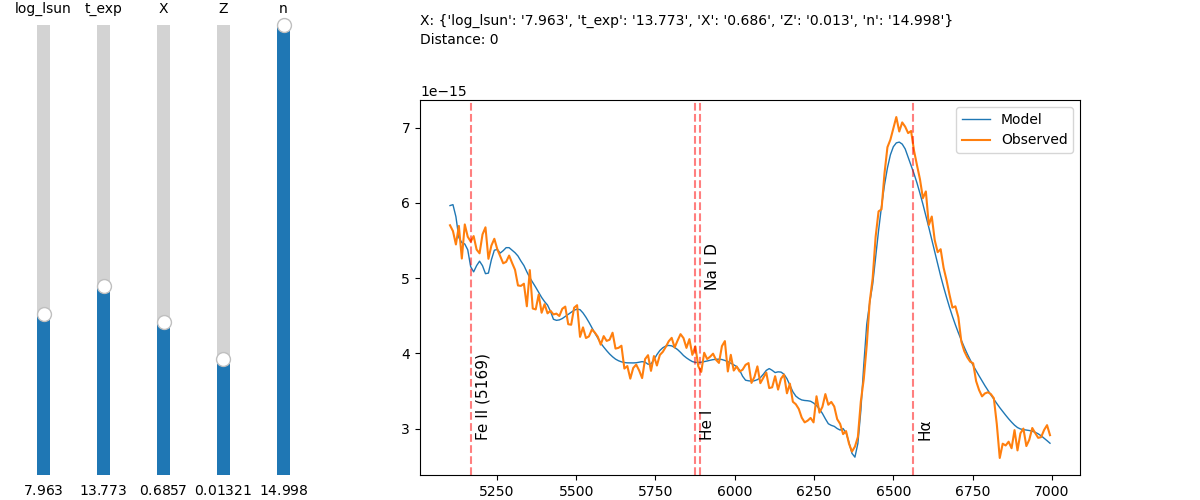

In [41]:
overlay_observed = True
show_interp = True
show_nearest = False
best_fit_ics = True
autoscale_view = False

# Initialize
from matplotlib.widgets import Slider
active_vals = None
if best_fit_ics:
    active_vals = X_mod
else:
    active_vals = sampler_start

fig, ax = plt.subplots(figsize=(12, 5))
fig.subplots_adjust(left=0.35, bottom=0.05, top=0.8)
fig.canvas.toolbar_position = 'bottom'

# Create figure elements
line1 = None
line2 = None
if show_interp:
    line1, = ax.plot(wav, np.empty_like(wav), lw=1, label='Model')
if show_nearest:
    line2, = ax.plot(wav, np.empty_like(wav), lw=1, label='Nearest')
if overlay_observed:
    ax.plot(wav, y_obs, label='Observed')
util.label_common_features()

text_X = ax.text(
    0, 1.2,
    'X: {}',
    transform=ax.transAxes
)

text_dist = ax.text(
    0, 1.15,
    'Distance: 0',
    transform=ax.transAxes
)

# Main update function
def redraw(initial=False):
    if line1:
        y_mod = continuum_removal(mlp_single(active_vals))
        line1.set_ydata(y_mod)

        vals_formatted = [f'{x:.3f}' for x in active_vals]
        text_X.set_text('X: ' + str(dict(zip(sampler_names, vals_formatted))))
        # text_dist.set_text('Distance: ' + str(util.distance(1/scale)))
    if line2:
        y_mod = continuum_removal(nearest_single(active_vals))
        line2.set_ydata(y_mod)

        if not line1:
            mask = np.isclose(y, y_mod).all(axis=1)
            index = np.where(mask)[0][0]
            vals_formatted = [f'{x:.3f}' for x in X[index]]
            text_X.set_text('X: ' + str(dict(zip(sampler_names, vals_formatted))))
            # text_dist.set_text('Distance: ' + str(util.distance(1/scale)))
    if autoscale_view or initial:
        ax.relim()
        ax.autoscale_view()
    fig.canvas.draw_idle()

# Make sliders
sliders = []
for index, name in enumerate(sampler_names):
    ax_slider = fig.add_axes([0.025 + 0.25 * index / 5, 0.05, 0.0225, 0.9])
    slider = Slider(
        ax=ax_slider,
        label=sampler_names[index],
        valmin=sampler_limits[index][0],
        valmax=sampler_limits[index][1],
        valinit=active_vals[index],
        orientation='vertical'
    )
    def make_update(index):
        def update(val):
            active_vals[index] = val
            redraw()
        return update
    slider.on_changed(make_update(index))
    sliders.append(slider)

redraw(True)
ax.legend()
plt.show()

In [49]:
print(sampler_input_indices)

{'log_lsun': 0, 't_exp': 1, 'v_start': 2, 'X': 3, 'Z': 4, 'n': 5}


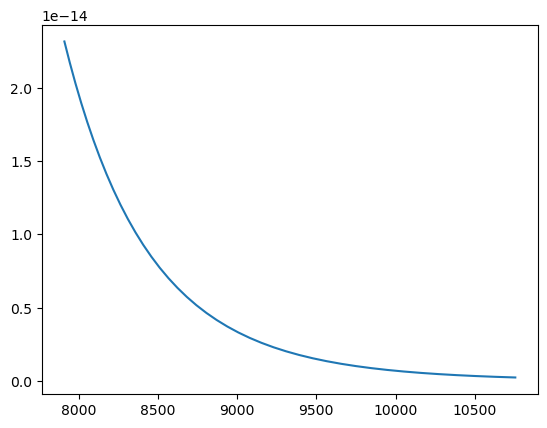

In [54]:
v_phot = util.calc_v_phot(t_exp=active_vals[sampler_input_indices['t_exp']], X=active_vals[sampler_input_indices['X']], n=active_vals[sampler_input_indices['n']])
# v_outer = 3 * v_phot
v_outer = util.calc_v_outer(v_phot=v_phot, n=active_vals[sampler_input_indices['n']])
rho_0 = 1.948e-14
v_0 = 8000.0
log_start = 3.0
velocities = np.logspace(log_start, np.log10(v_outer-v_phot+10**log_start), num=40+1) + v_phot - 10**log_start
densities = rho_0 * (velocities / v_0)**(-active_vals[sampler_input_indices['n']])

plt.figure()
plt.plot(velocities, densities)
show_active()

In [42]:
from astropy.constants import sigma_sb
def blackbody_L(t_exp, T, v):
    r = v*t_exp
    L = 4*np.pi*r**2 * sigma_sb * T**4
    return L.to(u.erg/u.s)

T = 6000 * u.K
v = 6000 * u.km/u.s
t_min = 13*u.day # param_limits[1][0] * u.day
t_max = 17.5*u.day # param_limits[1][1] * u.day
v_min = 6000*u.km/u.s
v_max = 7000*u.km/u.s

print('Best fit = 8.237')
L_min = blackbody_L(t_min, T, v_min)
L_max = blackbody_L(t_max, T, v_max)
print(t_min, ':', util.to_loglsun(L_min))
print(t_max, ':', util.to_loglsun(L_max))

Best fit = 8.237
13.0 d : 8.039671363429026
17.5 d : 8.431754335449169


# UltraNest Fit

In [ ]:
import ultranest
import ultranest.stepsampler
from ultranest.plot import cornerplot

# Gaussian prior, truncated Gaussian
def uniform_prior(quantile, min, max):
    return quantile * (max - min) + min
def log_uniform_prior(quantile, min, max):
    return 10**(quantile * (np.log10(max) - np.log10(min)) + np.log10(min))

def prior_transform(cube):
    params = cube.copy()
    for i in range(len(cube)):
        params[i] = uniform_prior(cube[i], *sampler_limits[i])
    return params

def likelihood(params):
    scale = 10**params[-1]
    active_vals = params[:-1]
    y_mod = mlp_single(active_vals)
    y1 = y_mod/scale
    y2 = y_obs
    y2err = y_obs_err
    like = -0.5 * (((y1 - y2) / y2err)**2).sum()
    return like

In [59]:
# Step sampler
sampler = ultranest.ReactiveNestedSampler(list(sampler_names), likelihood, prior_transform) #, log_dir='ultranest/1', storage_backend='csv')
sampler.stepsampler = ultranest.stepsampler.RegionSliceSampler(nsteps=2*ndim)

result = sampler.run()

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-4e+03  862.42 [-3863.2165..-3863.2146]*| it/evals=17614/766548 eff=2.2990% N=400      
[ultranest] Likelihood function evaluations: 766587
[ultranest]   logZ = -3902 +- 0.2197
[ultranest] Effective samples strategy satisfied (ESS = 3070.7, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.16 to 0.62, need <0.5)
[ultranest]   logZ error budget: single: 0.30 bs:0.22 tail:0.01 total:0.22 required:<0.50
[ultranest] done iterating.



logZ = -3902.417 +- 0.624
  single instance: logZ = -3902.417 +- 0.299
  bootstrapped   : logZ = -3902.380 +- 0.624
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations
step sampler diagnostic: jump distance 1.01 (should be >1), far enough fraction: 57.31% : fishy. Double nsteps and see if fraction and lnZ change)

    log_lsun            : 8.3567│ ▁▁▁▁▁▁▁▁▁▂▂▂▃▄▅▆▆▇▇▇▇▆▆▅▄▃▂▂▁▁▁▁▁  ▁▁ │8.3786    8.3678 +- 0.0026
    t_exp               : 17.4102│ ▁  ▁▁▁ ▁▁ ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▃▃▄▅▆▇│17.4993    17.4898 +- 0.0094
    v_start             : 6021.2│ ▁▁▁▁▁▁▁▁▂▃▃▄▄▅▆▆▇▇▇▆▆▅▅▄▃▃▂▂▁▁▁▁▁▁▁▁▁ │6063.2    6041.3 +- 5.5
    X                   : 0.8353│ ▁    ▁▁  ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▃▃▄▅▆▇│0.8500    0.8485 +- 0.0014
    Z                   : 0.00941│ ▁▁▁▁▁▁▁▂▃▄▅▅▇▆▇▆▅▅▄▄▃▃▂▂▁▁▁▁▁▁▁▁▁▁ ▁▁ │0.01438    0.01145 +- 0.00057
    n                   : 10.9833│ ▁      ▁ ▁▁▁▁▁ ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▃▄▆▇│10.9998    10.9984 +- 0.0014
    log_scale           : 5

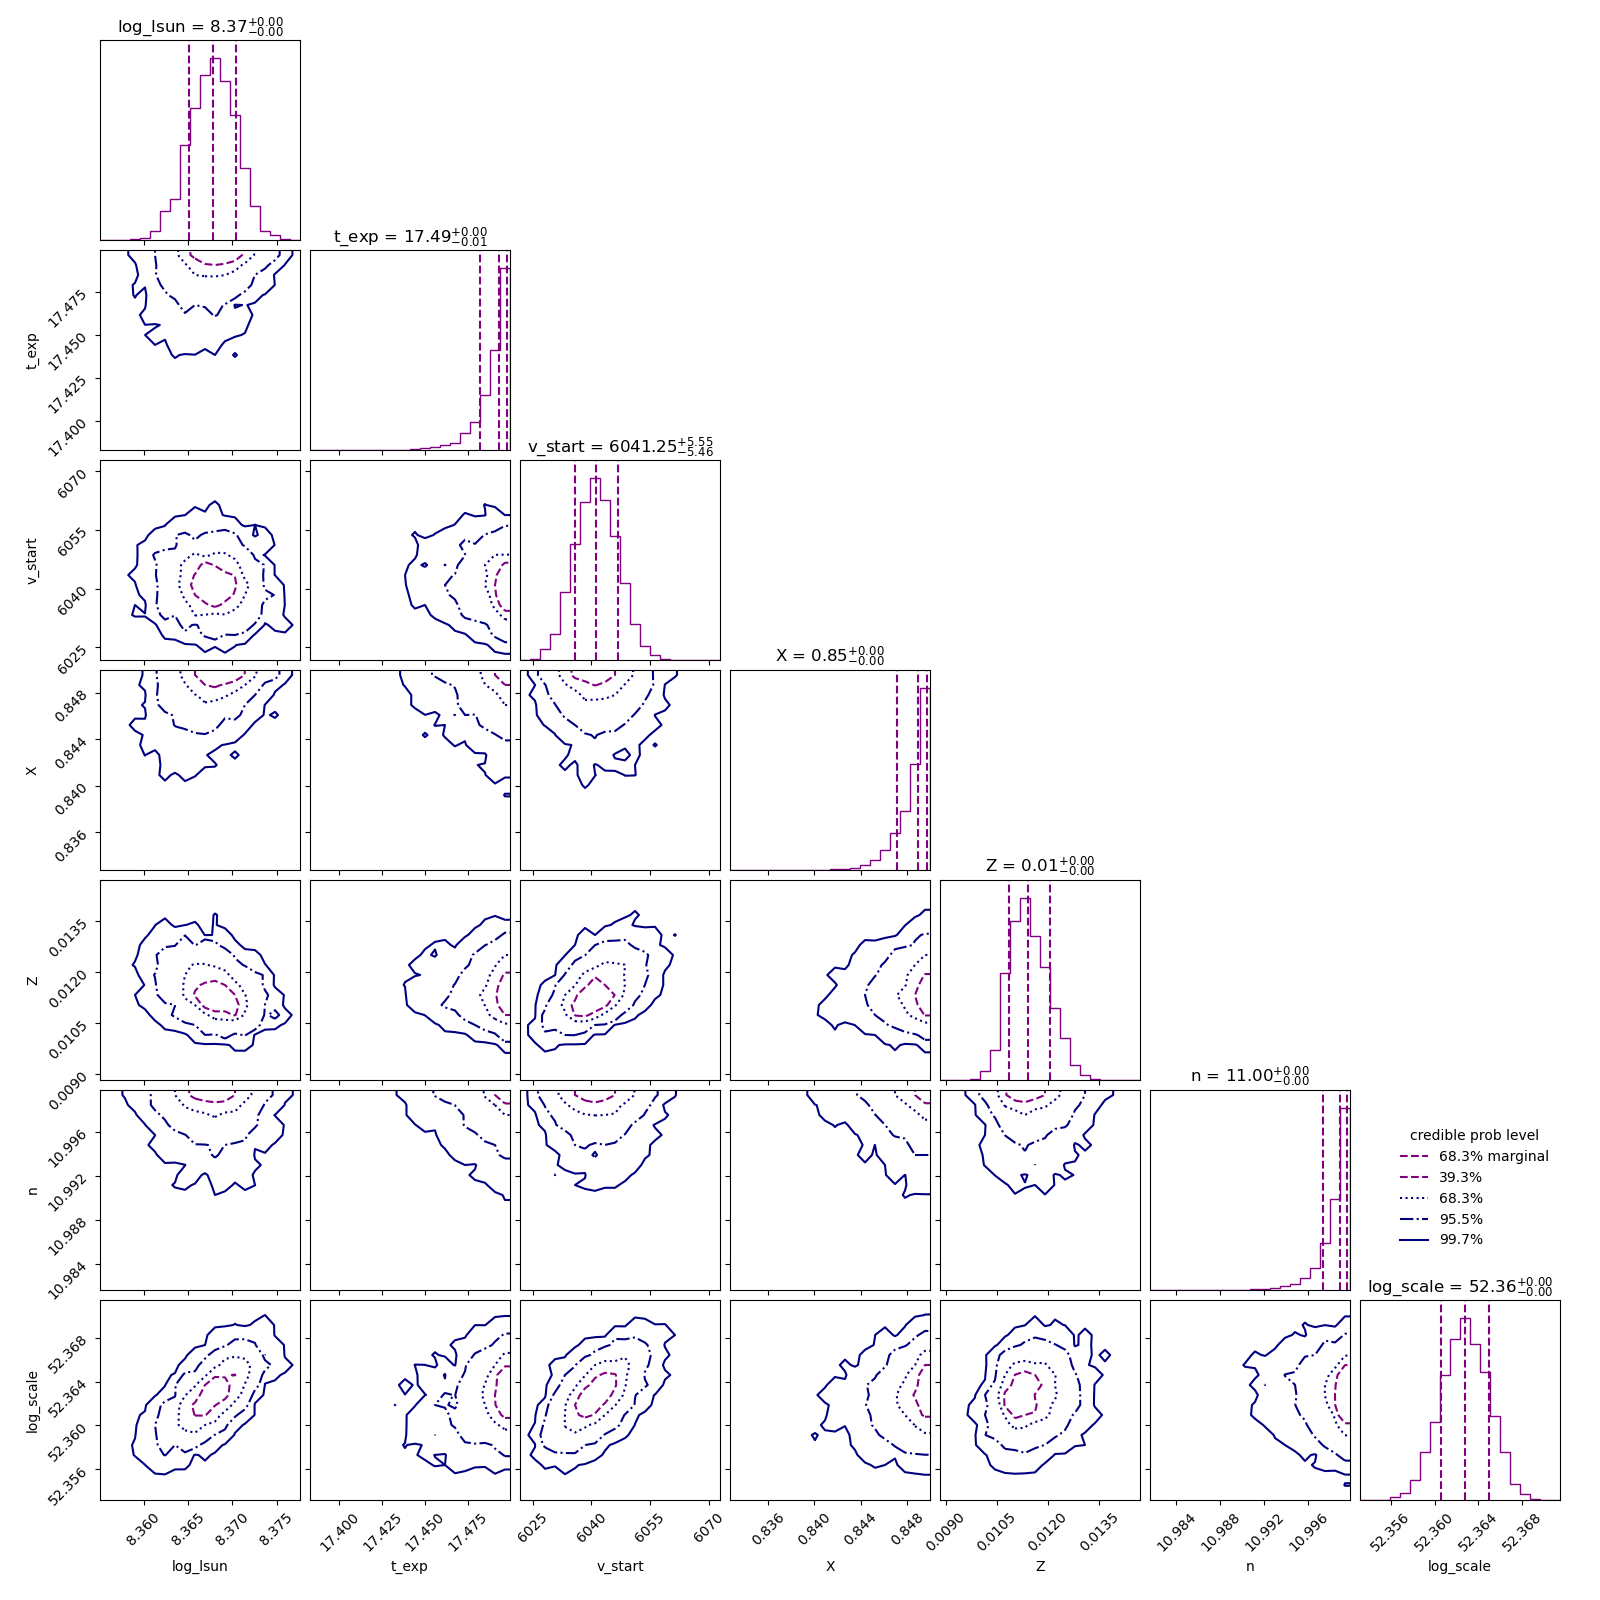

In [60]:
sampler.print_results()
sampler.plot_corner()

In [61]:
print(sampler.results.keys())
print(pd.DataFrame({'name': sampler_names, 'max likelihood': sampler.results['maximum_likelihood']['point']}))

dict_keys(['niter', 'logz', 'logzerr', 'logz_bs', 'logz_single', 'logzerr_tail', 'logzerr_bs', 'ess', 'H', 'Herr', 'posterior', 'weighted_samples', 'samples', 'maximum_likelihood', 'ncall', 'paramnames', 'logzerr_single', 'insertion_order_MWW_test'])
        name  max likelihood
0   log_lsun        8.370164
1      t_exp       17.497536
2    v_start     6038.344974
3          X        0.849922
4          Z        0.011108
5          n       10.999706
6  log_scale       52.363340


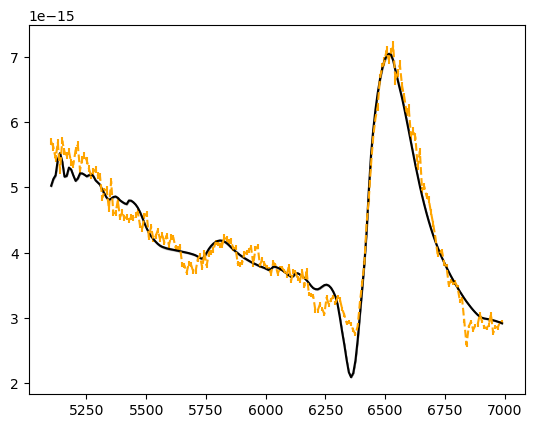

In [62]:
plt.figure()
plt.errorbar(wav, y_obs, yerr=np.abs(y_obs_err),
             marker='none', ls='--', color='orange')

from ultranest.plot import PredictionBand
band = PredictionBand(wav)

for X_i in sampler.results['samples']:
    scale = 10**X_i[-1]
    X_mod = X_i[:-1]
    y_mod = mlp_single(X_mod)
    band.add(y_mod / scale)

band.line(color='k')
# add 1 sigma quantile
band.shade(color='k', alpha=0.3)
# add wider quantile (0.01 .. 0.99)
band.shade(q=0.49, color='gray', alpha=0.2)

show_active()

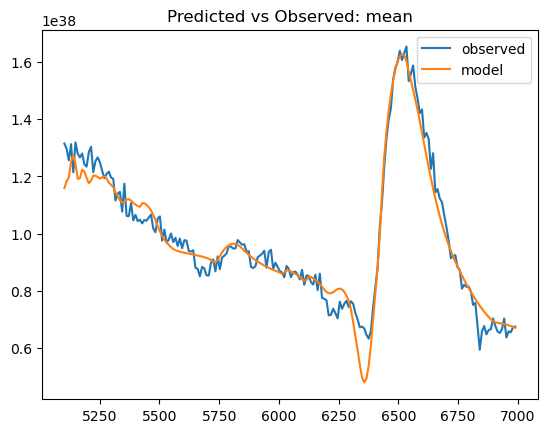

scale: 2.3055067583750386e+52
distance: 13.881222726188684 Mpc
X: [8.36426817e+00 1.74875848e+01 6.04537842e+03 8.46964193e-01
 1.12852285e-02 1.09959537e+01]


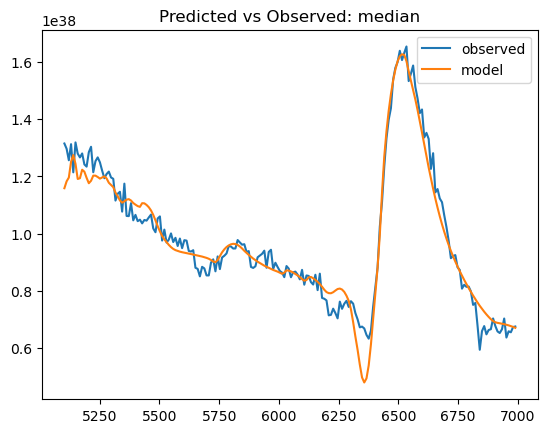

scale: 2.3056363952834614e+52
distance: 13.881612986051753 Mpc
X: [8.36426817e+00 1.74875848e+01 6.04537842e+03 8.46964193e-01
 1.12852285e-02 1.09959537e+01]


In [63]:
for type, params in (('mean', result['posterior']['mean']), ('median', result['posterior']['median'])):
    scale = 10**params[-1]
    active_vals = np.array(params[:-1])
    y_mod = mlp_single(active_vals)

    plt.figure()
    plt.plot(wav, y_obs * scale, label='observed')
    plt.plot(wav, y_mod, label='model')

    plt.title('Predicted vs Observed: ' + type)
    plt.legend()
    show_active()
    distance = util.distance(scale)
    
    print('scale:', scale)
    print('distance:', distance.to(u.Mpc))
    print('X:', X_mod)

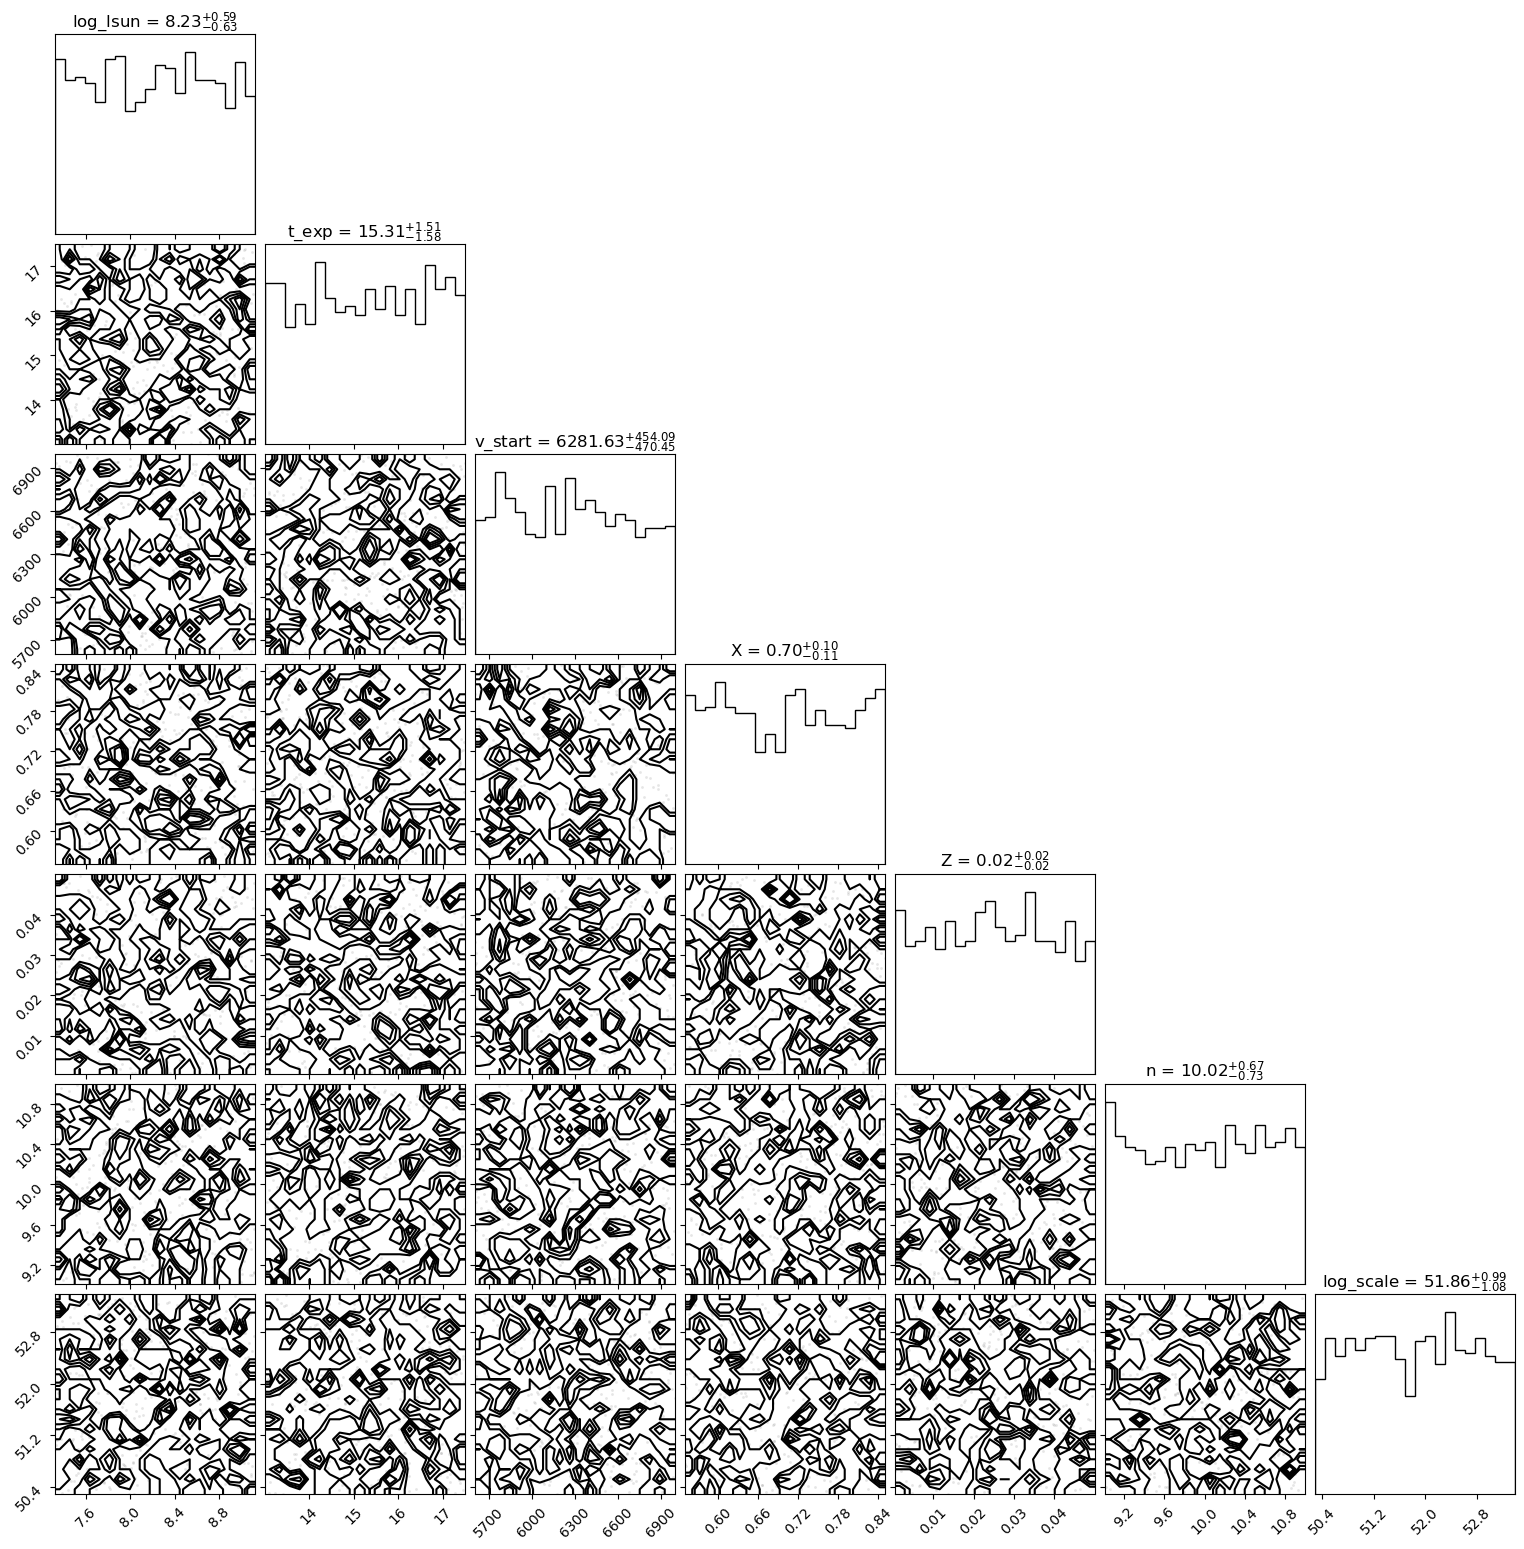

ValueError: X has 3 features, but StandardScaler is expecting 6 features as input.

In [64]:
# Diagnostics
def evaluate_performance():
    u = np.random.uniform(size=ndim)
    p = prior_transform(u)
    %timeit prior_transform(u)
    %timeit likelihood(p)
#evaluate_performance()

# Corner plot of a bunch of prior samples
p = np.array([prior_transform(np.random.uniform(size=ndim)) for i in range(1000)])
corner.corner(p, titles=sampler_names, show_titles=True, plot_density=False, quiet=True)
show_active()

# Plot evolution of likelihood over parameter range
vals = np.linspace(0, 1, 200)
p = np.array([prior_transform(np.array([0.5, v, 0.5, 0.5])) for v in vals])
like = np.array([likelihood(v) for v in p])

plt.figure()
plt.plot(vals, like)
show_active()